In [1]:
import sys
from pathlib import Path
prediction_mode_path = Path("../module") #add additional . :)
sys.path.append(prediction_mode_path.as_posix())
import models_creation as pred_model

import pandas as pd
import numpy as np

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.model_selection import train_test_split
import math

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
#from sklearn import tree

from matplotlib import pyplot as plt

import joblib

from mordred import Calculator, descriptors
import mordred
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem import Draw

import warnings
warnings.filterwarnings('ignore')

# EE

In [2]:
molecular_descriptors_df = pred_model.prepare_data('../Data/QSPR_epoxidation_model_III.xlsx')

  2%|█▎                                                                                 | 1/62 [00:01<01:20,  1.31s/it]

C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 63%|███████████████████████████████████████████████████▌                              | 39/62 [00:01<00:01, 12.92it/s]

C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaco

100%|██████████████████████████████████████████████████████████████████████████████████| 62/62 [00:01<00:00, 34.60it/s]


C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
Data size (rows, columns): (62, 3874)
Data size after first reduction (rows, columns): (62, 3227)
Data size after second reduction (rows, columns): (62, 1340)


In [3]:
target = 'ee'
data = molecular_descriptors_df
#data[target] = load_prepared_data['ee']
data.head()

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,C_FP_1991,C_FP_1992,C_FP_1996,C_FP_1999,C_FP_2017,C_FP_2023,C_FP_2029,C_FP_2033,C_FP_2041,ee
0,26.682927,5.770088,3.024390,6.178260,153.267812,105.649934,1.844467,5.906402,3.601607,7.350701,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,80.0
1,25.935484,5.706245,2.580645,4.751892,158.057747,102.435555,1.691055,5.821371,3.519689,7.342506,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46.0
2,23.860465,5.661247,2.744186,4.914154,157.443307,94.120542,1.670321,5.779477,3.312805,7.283060,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,95.0
3,24.764706,5.671282,2.529412,4.450254,158.718230,97.699954,1.650025,5.783676,3.334128,7.311622,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0
4,24.764706,5.671282,2.588235,4.567901,158.718230,97.699954,1.650025,5.783676,3.349651,7.311622,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,82.0


## The best model is: Random Forest (correlation_threshold = 0.41, 2 features, 8 estimators, random_state=15)

In [4]:
model, train_r2_, test_r2_, hist1, hist2, target_column_name, training_data_RMSE, test_data_RMSE  = pred_model.prepare_data_and_create_model(molecular_descriptors_df=data, 
                                                                                                    correlation_threshold=0.41, 
                                                                                                    standardization=False, 
                                                                                                    model_type='RandomForestRegressor',
                                                                                                    target_column_name = target,
                                                                                                    n_estimators_ = 8,
                                                                                                    random_state=15,
                                                                                                    train_test_split_=True, 
                                                                                                    verbose=True)
print("R^2 score: " + str(r2_score(data[target], model.predict(data[hist2['molecular descriptor name']]))))
print("Mean squared error: "+str(mean_squared_error(data[target], model.predict(data[hist2['molecular descriptor name']]))))
print('Mean absolute error: ' + str(mean_absolute_error(data[target], model.predict(data[hist2['molecular descriptor name']]))))
print("Root Mean Square Error: "+ str(math.sqrt(mean_squared_error(data[target], model.predict(data[hist2['molecular descriptor name']])))))

I am not doing standardization...
  molecular descriptor name
0                    AATS0Z
1                  AATS0are
2                    AATS0d
3                   AATS0dv
4                    AATS0i
  molecular descriptor name  corr_value
0                    AATS0Z   -0.002226
1                  AATS0are   -0.105080
2                    AATS0d   -0.008581
3                   AATS0dv   -0.065079
4                    AATS0i   -0.139124
  molecular descriptor name  corr_value  absolute correlation value
0                    AATS0Z   -0.002226                    0.002226
1                  AATS0are   -0.105080                    0.105080
2                    AATS0d   -0.008581                    0.008581
3                   AATS0dv   -0.065079                    0.065079
4                    AATS0i   -0.139124                    0.139124
     molecular descriptor name  corr_value  absolute correlation value
355                     ATSC5v    0.419292                    0.419292
706     

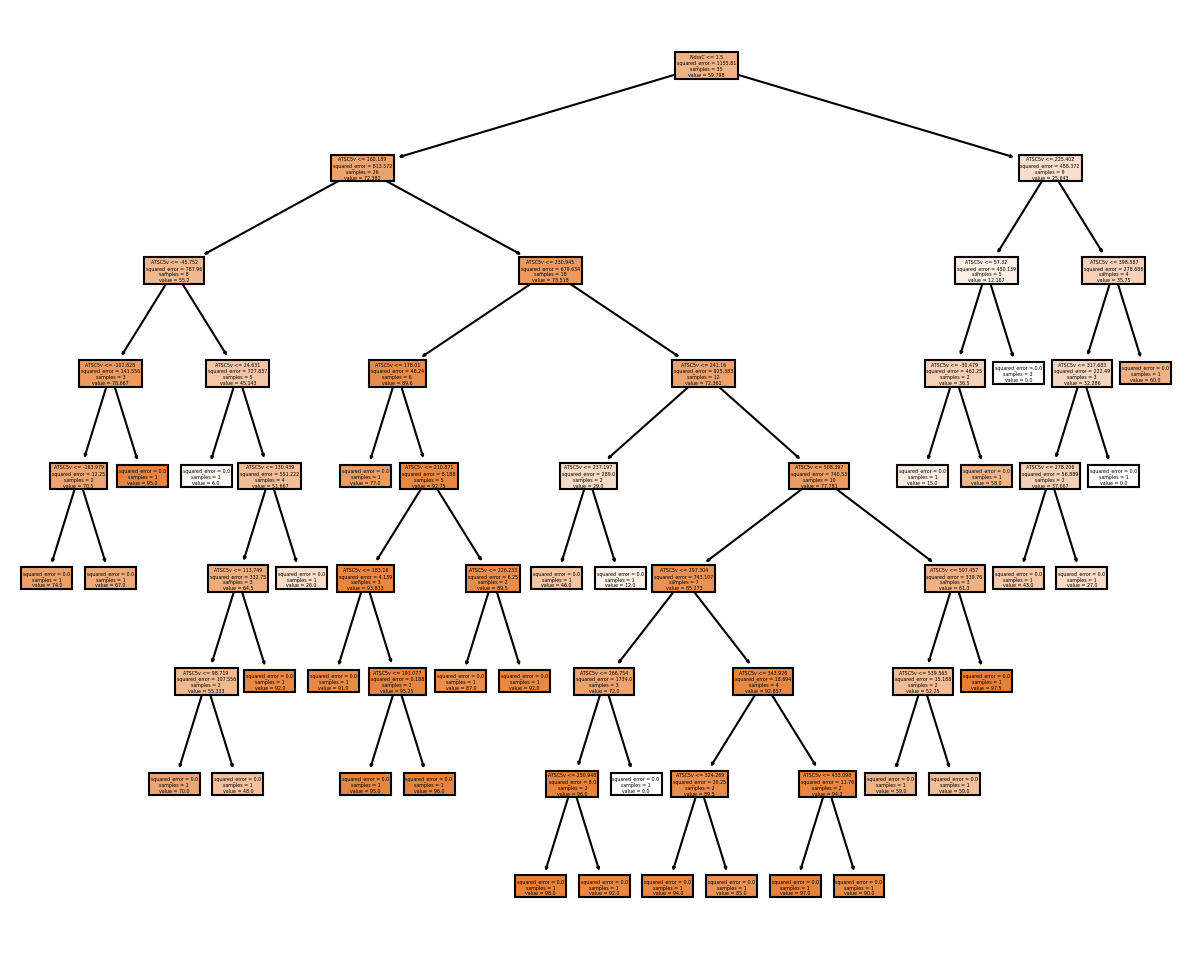

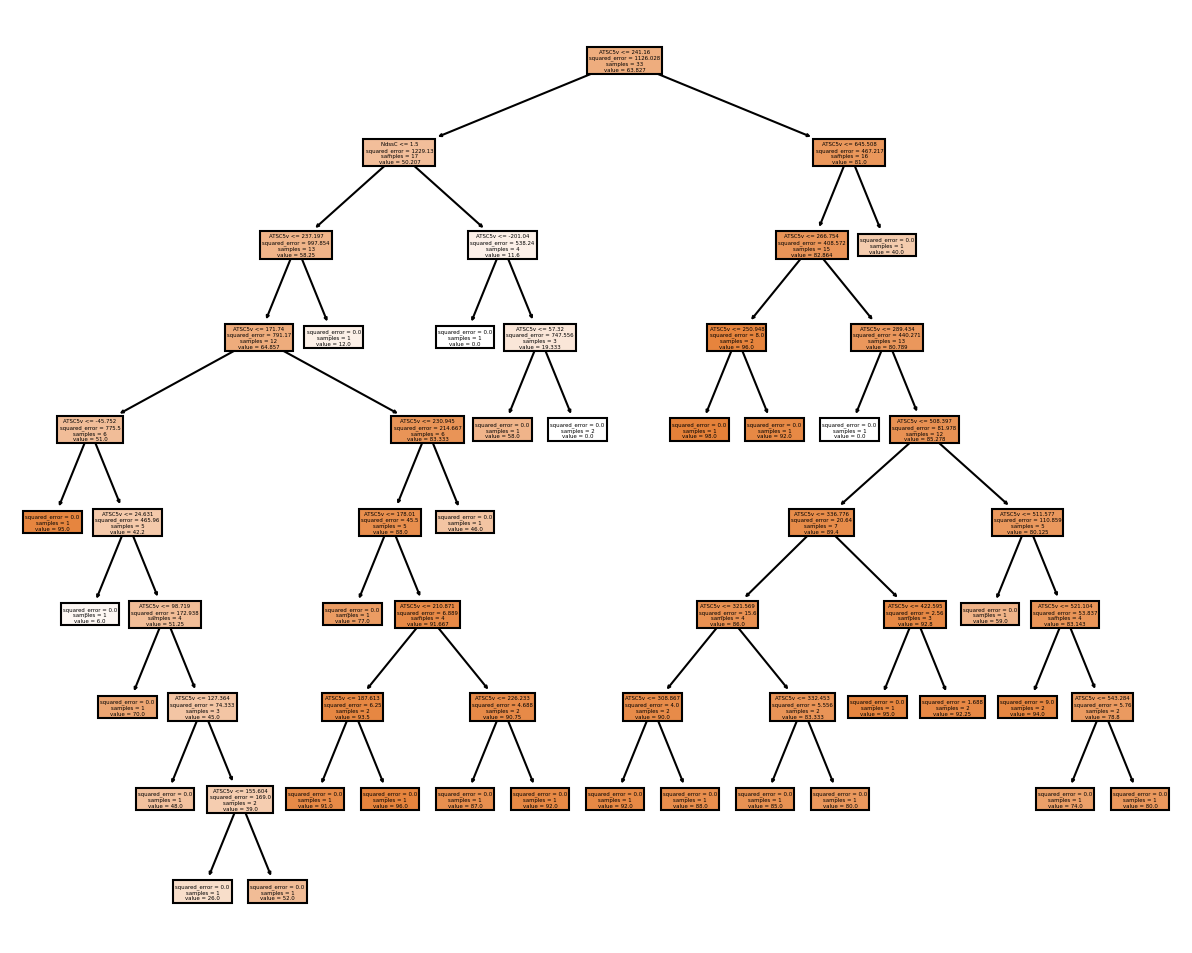

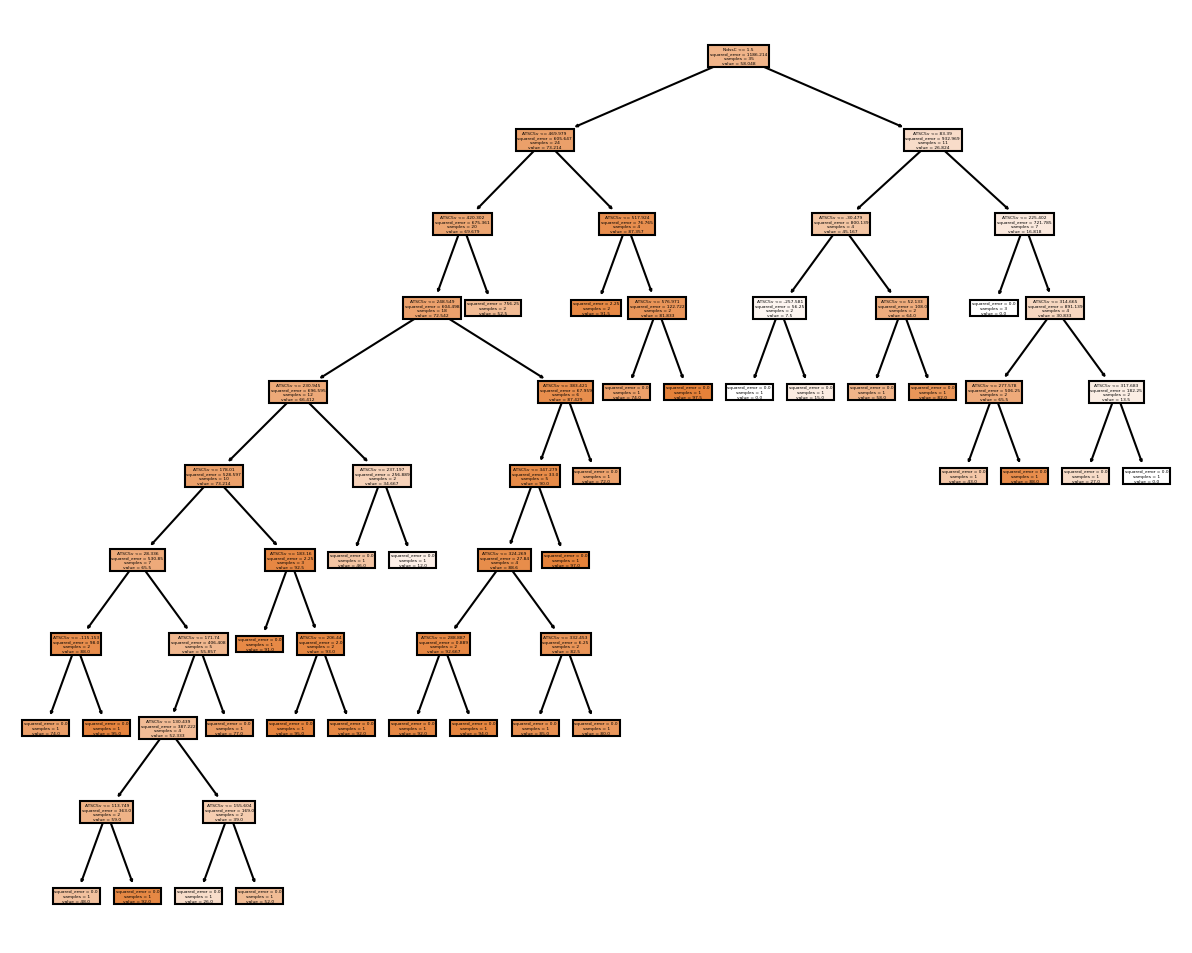

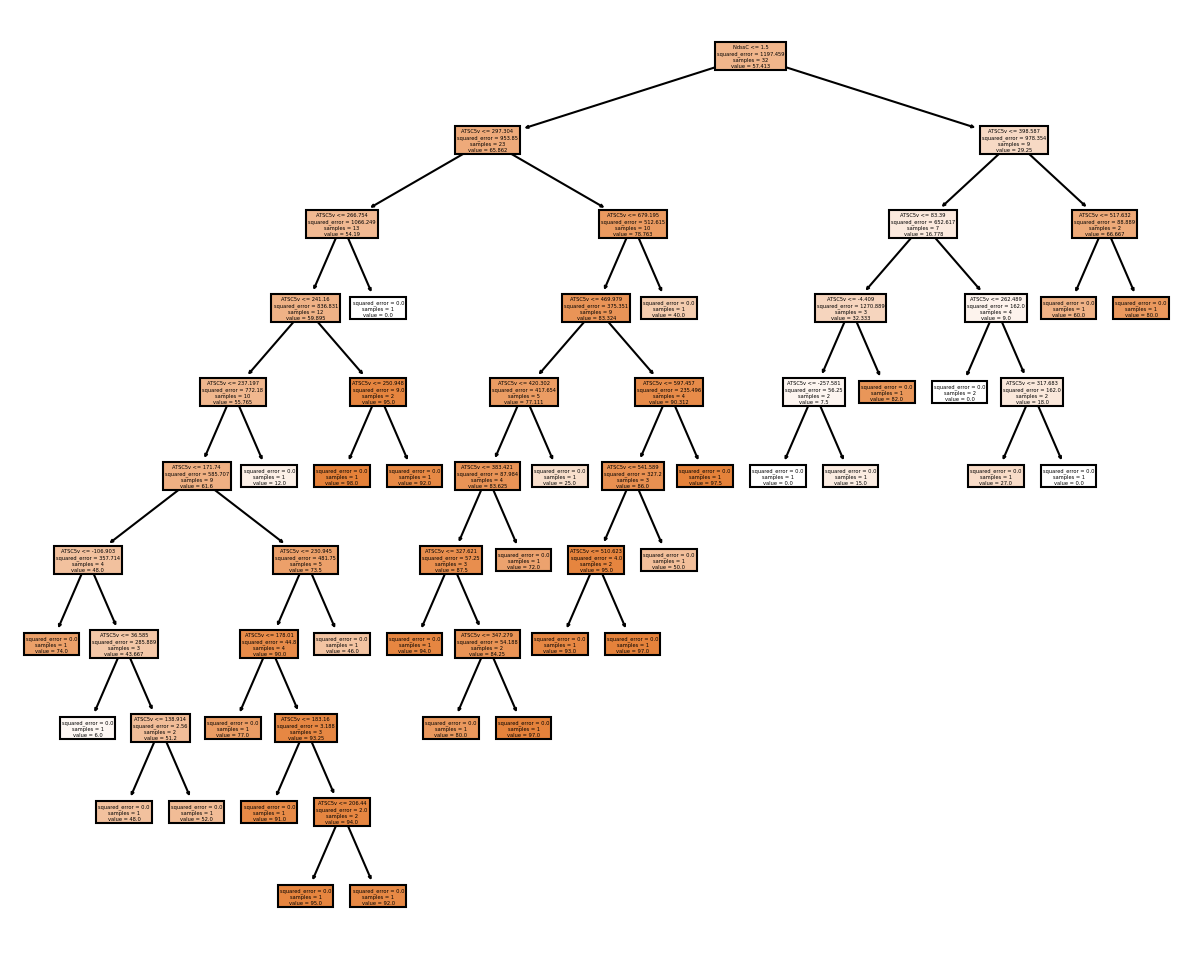

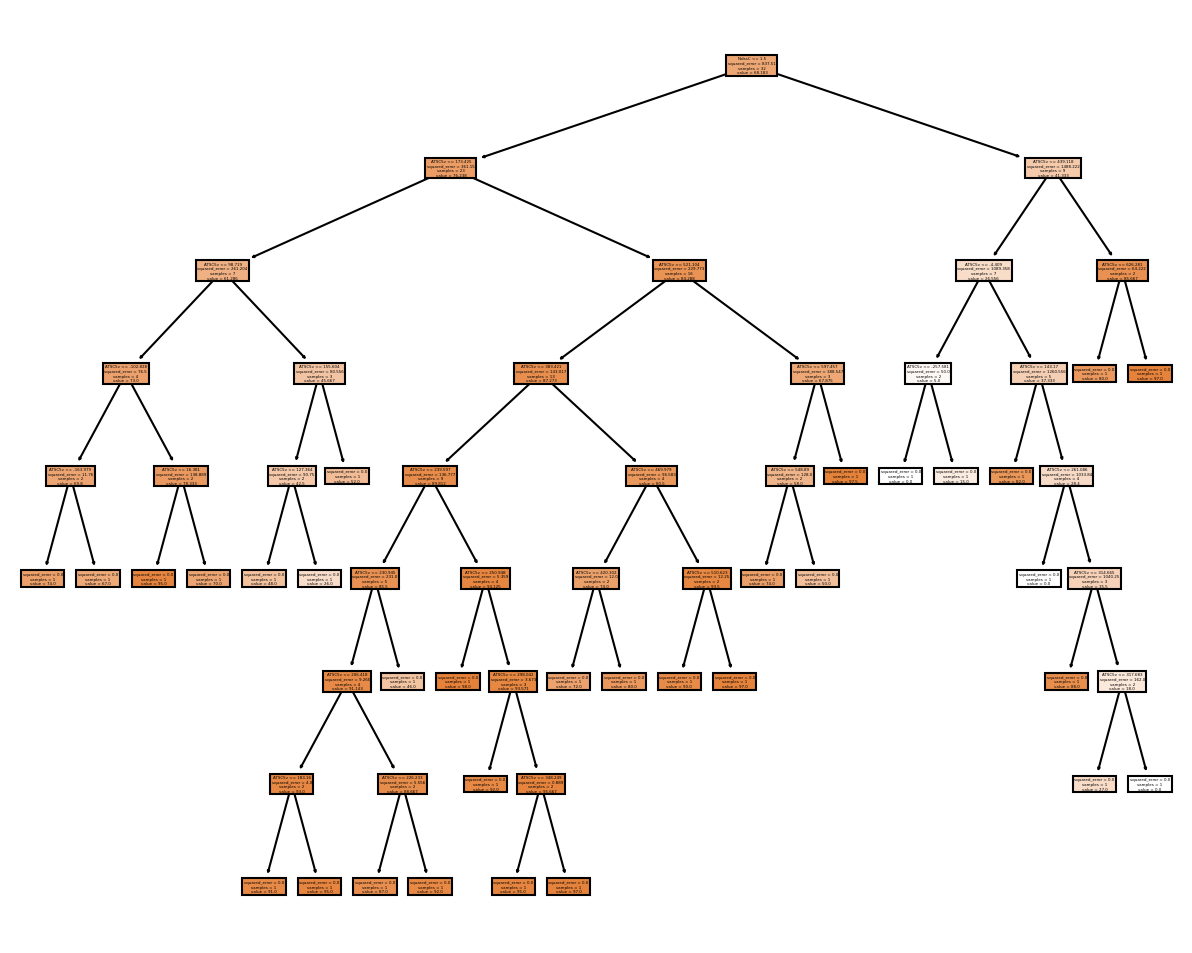

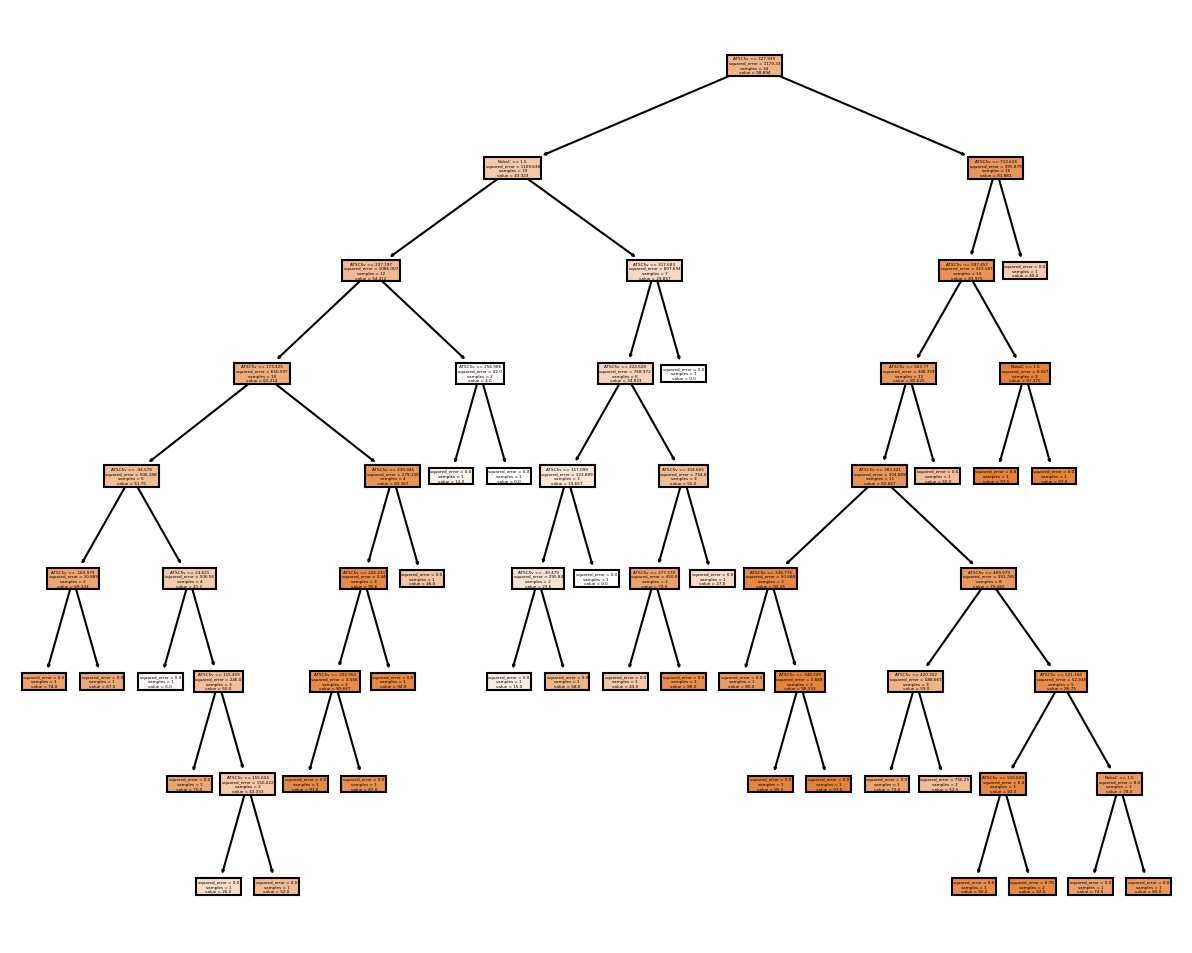

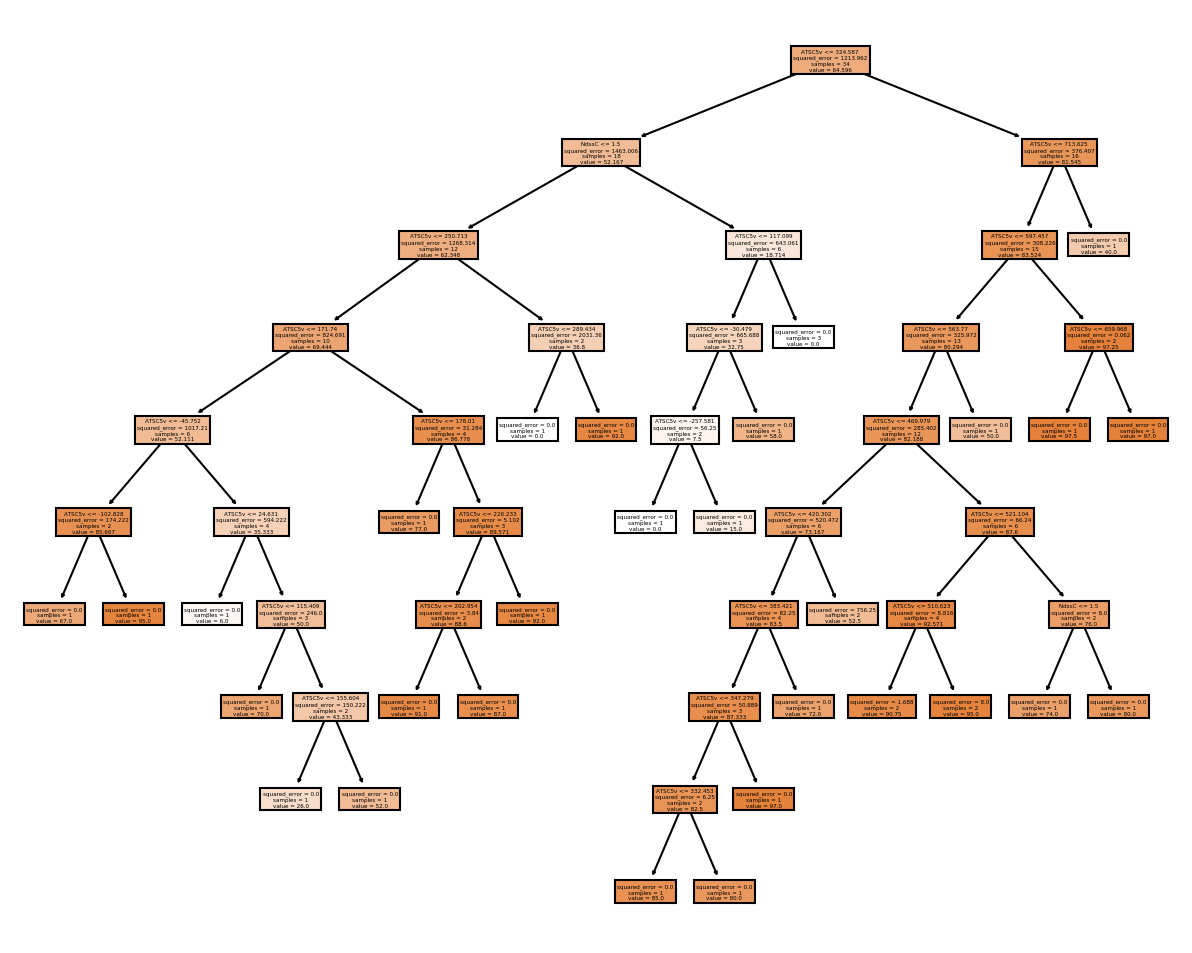

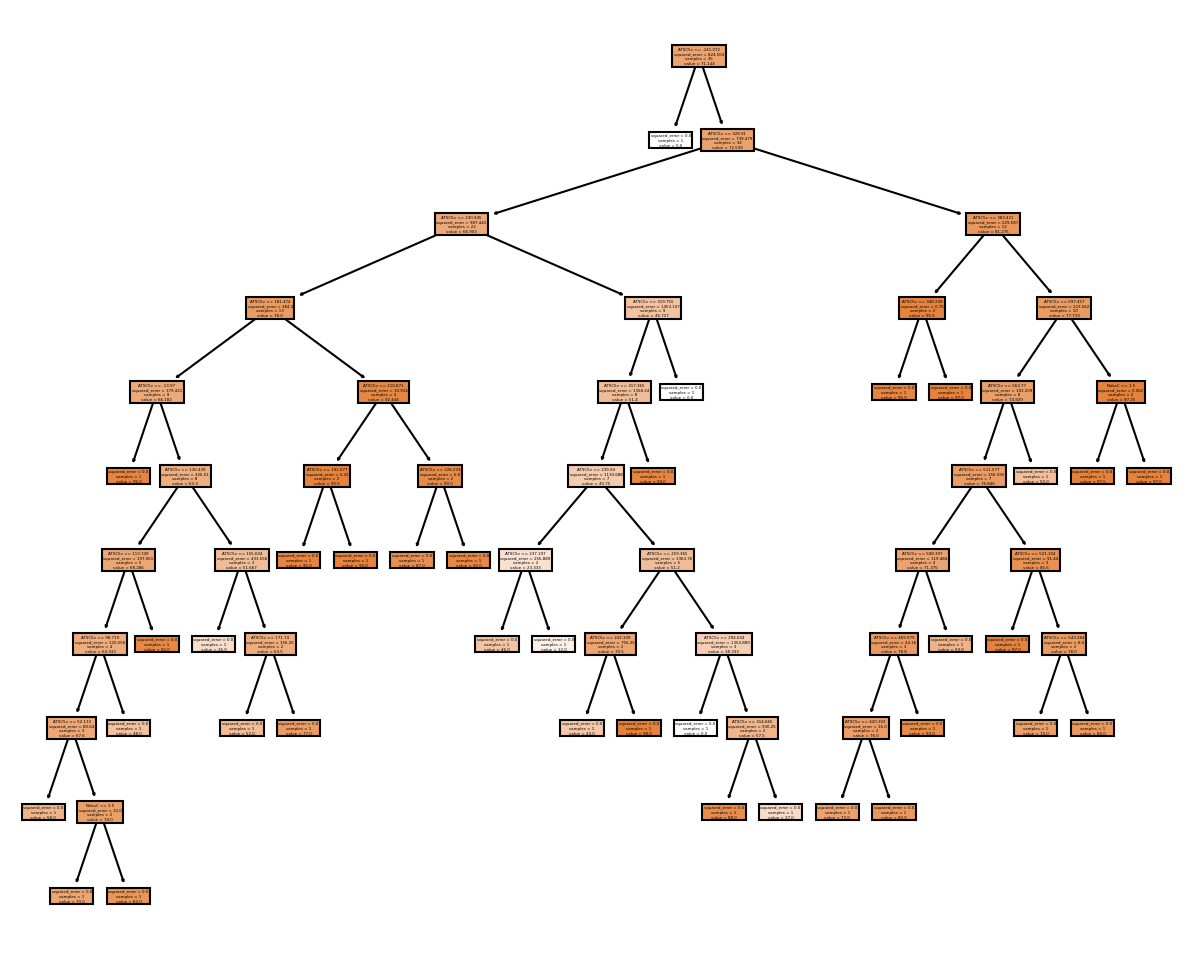

In [5]:
# save
joblib.dump(model, "models/random_forest_model_8_estimators_EE.joblib")
for x, decision_tree in enumerate(model.estimators_):
    plt.figure(figsize=(10,8), dpi=150)
    plot_tree(decision_tree, feature_names=list(hist2['molecular descriptor name']),
             filled=True)
    plt.savefig('models/random_forest_8_'+str(x)+'_model_EE.pdf',bbox_inches = "tight")

In [6]:
list(hist2['molecular descriptor name'])

['ATSC5v', 'NdssC']

In [7]:
load_unseen_data = pd.read_excel('../Data/5_test_reactions.xlsx')
df_unseen = load_unseen_data[['SMILES', 'ee']]
df__ = pred_model.prepare_data('../Data/5_test_reactions.xlsx')
predicted_activity = model.predict(df__[hist2['molecular descriptor name']])
df_unseen['Predicted ee'] = predicted_activity

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  6.97it/s]


C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
Data size (rows, columns): (5, 3874)
Data size after first reduction (rows, columns): (5, 3229)
Data size after second reduction (rows, columns): (5, 1012)


In [8]:
df__[hist2['molecular descriptor name']]

,ATSC5v,NdssC
0,77.024215,1
1,399.430328,1
2,261.494898,1
3,293.850547,1
4,186.768634,2


In [9]:
df_unseen

,SMILES,ee,Predicted ee
0,O=C1CCC=C1.SCC2=CC=CC=C2,80,64.500
1,CC1=CC=CC=C1CS.O=C(\C=C\C1=CC=CC=C1)C1=CC=CC=C1,98,78.000
2,O=C(C1=CC=CC=C1)C=CC2=CC=CC=C2N(=O)=O.SCC3=CC=...,46,57.500
3,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2.NCCS,0,46.250
4,SCC1(CC1)CC(OC)=O.O=C(/C=C/C2=CC(C3SCCCS3)=CC=...,22,11.875


In [10]:
print("R^2 score: " + str(r2_score(df_unseen['ee'], df_unseen['Predicted ee'])))
print("Mean squared error: "+str(mean_squared_error(df_unseen['ee'], df_unseen['Predicted ee'])))
print('Mean absolute error: ' + str(mean_absolute_error(df_unseen['ee'], df_unseen['Predicted ee'])))
print("Root Mean Square Error: "+ str(math.sqrt(mean_squared_error(df_unseen['ee'], df_unseen['Predicted ee']))))

R^2 score: 0.5363527373554025
Mean squared error: 602.815625
Mean absolute error: 20.675
Root Mean Square Error: 24.5523038633852


In [11]:
df_unseen = df_unseen.iloc[[0,1,2,4]]

In [12]:
df_unseen

,SMILES,ee,Predicted ee
0,O=C1CCC=C1.SCC2=CC=CC=C2,80,64.500
1,CC1=CC=CC=C1CS.O=C(\C=C\C1=CC=CC=C1)C1=CC=CC=C1,98,78.000
2,O=C(C1=CC=CC=C1)C=CC2=CC=CC=C2N(=O)=O.SCC3=CC=...,46,57.500
4,SCC1(CC1)CC(OC)=O.O=C(/C=C/C2=CC(C3SCCCS3)=CC=...,22,11.875


In [13]:
print("R^2 score: " + str(r2_score(df_unseen['ee'], df_unseen['Predicted ee'])))
print("Mean squared error: "+str(mean_squared_error(df_unseen['ee'], df_unseen['Predicted ee'])))
print('Mean absolute error: ' + str(mean_absolute_error(df_unseen['ee'], df_unseen['Predicted ee'])))
print("Root Mean Square Error: "+ str(math.sqrt(mean_squared_error(df_unseen['ee'], df_unseen['Predicted ee']))))

R^2 score: 0.7481969424460432
Mean squared error: 218.75390625
Mean absolute error: 14.28125
Root Mean Square Error: 14.790331512511814
